In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [31]:
df = pd.read_csv("data/charging_sessions.csv")

## Find duplicate values

In [32]:
new_df=df.copy()
duplicates = new_df[new_df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Unnamed: 0, id, connectionTime, disconnectTime, doneChargingTime, kWhDelivered, sessionID, siteID, spaceID, stationID, timezone, userID, userInputs]
Index: []


## Add columns for charging time, connection time and idle time. 

In [33]:
new_df['disconnectTime'] = pd.to_datetime(new_df['disconnectTime']).dt.tz_localize(None)
new_df['connectionTime'] = pd.to_datetime(new_df['connectionTime']).dt.tz_localize(None)
new_df['doneChargingTime']=pd.to_datetime(new_df['doneChargingTime']).dt.tz_localize(None)
new_df['Connection_Time'] = new_df['disconnectTime'] - new_df['connectionTime']
new_df['Charging_Time']=new_df['doneChargingTime']-new_df['connectionTime']
new_df['Idle_Time']=new_df['Connection_Time']-new_df['Charging_Time']
print(new_df.head())

   Unnamed: 0                        id      connectionTime  \
0           0  5e23b149f9af8b5fe4b973cf 2020-01-02 13:08:54   
1           1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
2           2  5e23b149f9af8b5fe4b973d1 2020-01-02 13:56:35   
3           3  5e23b149f9af8b5fe4b973d2 2020-01-02 13:59:58   
4           4  5e23b149f9af8b5fe4b973d3 2020-01-02 14:00:01   

       disconnectTime    doneChargingTime  kWhDelivered  \
0 2020-01-02 19:11:15 2020-01-02 17:31:35        25.016   
1 2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
2 2020-01-03 00:39:22 2020-01-02 16:35:06         6.521   
3 2020-01-02 16:38:39 2020-01-02 15:18:45         2.355   
4 2020-01-02 22:08:40 2020-01-02 18:17:30        13.375   

                                sessionID  siteID  spaceID    stationID  \
0  1_1_179_810_2020-01-02 13:08:53.870034       1  AG-3F30  1-1-179-810   
1  1_1_193_825_2020-01-02 13:36:49.599853       1  AG-1F01  1-1-193-825   
2  1_1_193_829_2020-01-02 13:56:35.214993

In [34]:
new_df['Connection_Time_minutes'] = new_df['Connection_Time'].dt.total_seconds() / 60
new_df['Charging_Time_minutes'] = new_df['Charging_Time'].dt.total_seconds() / 60
new_df['Idle_Time_minutes'] = new_df['Idle_Time'].dt.total_seconds() / 60
print(new_df[['Charging_Time','Connection_Time','Idle_Time','Connection_Time_minutes','Charging_Time_minutes','Idle_Time_minutes']])

        Charging_Time Connection_Time         Idle_Time  \
0     0 days 04:22:41 0 days 06:02:21   0 days 01:39:40   
1     0 days 06:41:15 0 days 09:01:31   0 days 02:20:16   
2     0 days 02:38:31 0 days 10:42:47   0 days 08:04:16   
3     0 days 01:18:47 0 days 02:38:41   0 days 01:19:54   
4     0 days 04:17:29 0 days 08:08:39   0 days 03:51:10   
...               ...             ...               ...   
66445 0 days 05:22:14 0 days 05:21:14 -1 days +23:59:00   
66446 0 days 03:03:42 0 days 06:19:01   0 days 03:15:19   
66447 0 days 03:40:41 0 days 03:39:42 -1 days +23:59:01   
66448 0 days 02:05:43 0 days 05:15:04   0 days 03:09:21   
66449 0 days 01:29:47 0 days 02:38:17   0 days 01:08:30   

       Connection_Time_minutes  Charging_Time_minutes  Idle_Time_minutes  
0                   362.350000             262.683333          99.666667  
1                   541.516667             401.250000         140.266667  
2                   642.783333             158.516667         484.

In [35]:
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66450 non-null  int64          
 1   id                       66450 non-null  object         
 2   connectionTime           66450 non-null  datetime64[ns] 
 3   disconnectTime           66450 non-null  datetime64[ns] 
 4   doneChargingTime         62362 non-null  datetime64[ns] 
 5   kWhDelivered             66450 non-null  float64        
 6   sessionID                66450 non-null  object         
 7   siteID                   66450 non-null  int64          
 8   spaceID                  66450 non-null  object         
 9   stationID                66450 non-null  object         
 10  timezone                 66450 non-null  object         
 11  userID                   49187 non-null  float64        
 12  userInputs        

## Analyse Charging Time
### From the table below, it is evident that some Charging Time and Idle Time values are negative, indicating data errors. 

In [36]:
print("\nStatisitcal Summary:")
print(new_df.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count  66450.000000                          66450   
mean    4726.102062  2019-08-06 20:19:01.997832704   
min        0.000000            2018-04-25 11:08:04   
25%     1845.000000     2018-11-13 08:28:56.500000   
50%     3960.000000     2019-06-14 14:17:45.500000   
75%     7027.000000     2020-01-08 00:31:54.500000   
max    15291.000000            2021-09-14 05:43:39   
std     3568.025394                            NaN   

                      disconnectTime               doneChargingTime  \
count                          66450                          62362   
mean   2019-08-07 02:36:36.576042240  2019-07-26 00:28:10.348946432   
min              2018-04-25 13:20:10            2018-04-25 13:21:10   
25%              2018-11-13 19:00:42  2018-11-15 10:24:38.249999872   
50%              2019-06-14 22:00:46            2019-06-05 20:53:37   
75%              2020-01-08 03:36:08  2019-12-17 18:40:35.2499998

### There are 27 rows where doneChargingTime is earlier than connectionTime.

In [37]:
print(new_df[new_df['Charging_Time_minutes'] < 0])

       Unnamed: 0                        id      connectionTime  \
22219        2040  5c942ca4f9af8b06b04b3bb4 2019-03-05 19:13:55   
22253        2074  5c957e1cf9af8b42f440af03 2019-03-06 20:26:30   
23562        3383  5cca3a22f9af8b49aaa4cba0 2019-04-15 20:24:13   
23586        3407  5ccb8ba6f9af8b4d9721df00 2019-04-16 16:11:08   
27689        7510  5d856f1ff9af8b0c7bdf245c 2019-09-04 16:35:04   
27740        7561  5d86c0a5f9af8b1022a81870 2019-09-05 18:44:57   
29295        9116  5dcdffbdf9af8b220a19be8b 2019-10-29 17:22:32   
31285         492  5bc91740f9af8b0dc677b860 2018-05-04 19:08:37   
31287         494  5bc91740f9af8b0dc677b862 2018-05-04 19:23:52   
31403         610  5bc917d0f9af8b0dc677b8d6 2018-05-07 20:47:51   
35840        5047  5bc92c03f9af8b0dc677ca2b 2018-07-19 15:57:19   
38884        8091  5bc937f6f9af8b0dc677d60f 2018-08-29 05:25:08   
39875        9082  5bc93c1cf9af8b0dc677d9ee 2018-09-11 15:15:01   
41263       10470  5bc94185f9af8b0dc677df5a 2018-09-27 22:58:4

### There are 4692 rows where disconnectTime is earlier than doneChargingTime.

In [38]:
print(new_df[new_df['Idle_Time_minutes'] < 0])

       Unnamed: 0                        id      connectionTime  \
12             12  5e23b149f9af8b5fe4b973db 2020-01-02 15:04:38   
20             20  5e23b149f9af8b5fe4b973e3 2020-01-02 15:28:47   
25             25  5e23b149f9af8b5fe4b973e8 2020-01-02 15:42:05   
26             26  5e23b149f9af8b5fe4b973e9 2020-01-02 15:57:24   
33             33  5e23b149f9af8b5fe4b973f0 2020-01-02 16:34:35   
...           ...                       ...                 ...   
66432       10070  5d574ad2f9af8b4c10c03645 2019-07-31 14:36:02   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   
66447       10085  5d574ad2f9af8b4c10c03654 2019-07-31 19:04:40   

           disconnectTime    doneChargingTime  kWhDelivered  \
12    2020-01-02 22:08:39 2020-01-02 22:09:36        25.567   
20    2020-01-02 19:01:54 2020-01-02 19:02:51         7.417   
25    

### According to business logic, doneChargingTime cannot be earlier than connectionTime. Therefore, we delete 27 rows where doneChargingTime is earlier than connectionTime.

In [39]:
new_df = new_df.drop(new_df[new_df['Charging_Time_minutes'] < 0].index)
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         62335 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   49181 non-null  float64        
 12  userInputs             

## Filling null values(doneChargingTime)

In [40]:
print(new_df.describe())

         Unnamed: 0                 connectionTime  \
count  66423.000000                          66423   
mean    4724.823510  2019-08-06 22:33:04.837872128   
min        0.000000            2018-04-25 11:08:04   
25%     1845.000000     2018-11-13 14:23:23.500000   
50%     3959.000000            2019-06-14 14:33:06   
75%     7025.000000            2020-01-08 03:38:57   
max    15291.000000            2021-09-14 05:43:39   
std     3567.026437                            NaN   

                      disconnectTime               doneChargingTime  \
count                          66423                          62335   
mean   2019-08-07 04:50:35.555425280  2019-07-26 02:43:38.167642368   
min              2018-04-25 13:20:10            2018-04-25 13:21:10   
25%              2018-11-13 21:18:27            2018-11-15 17:18:23   
50%              2019-06-14 22:45:07            2019-06-05 21:40:58   
75%              2020-01-08 06:05:22            2019-12-17 18:57:21   
max             

From the table, it can be observed that the Charging_Time_minutes column contains significant outliers. To avoid the influence of these extreme values, we choose to fill the missing values with the median.

In [41]:
charging_time_median = new_df['Charging_Time_minutes'].median()
new_df['Charging_Time_minutes'] = new_df['Charging_Time_minutes'].fillna(value=charging_time_median)
new_df['doneChargingTime'] = new_df['doneChargingTime'].fillna(value=new_df['connectionTime'] + pd.to_timedelta(new_df['Charging_Time_minutes'], unit='m'))
new_df['Idle_Time_minutes']=new_df['Idle_Time_minutes'].fillna(value=new_df['Connection_Time_minutes']-new_df['Charging_Time_minutes'])
new_df['Charging_Time']=new_df['Charging_Time'].fillna(value=new_df['doneChargingTime']-new_df['connectionTime'])
new_df['Idle_Time']=new_df['Idle_Time'].fillna(new_df['Connection_Time']-new_df['Charging_Time'])
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   49181 non-null  float64        
 12  userInputs             

## Filling null values(userID and userInputs)

In [42]:
new_df['userID'] = new_df['userID'].fillna(value=-1)
new_df['userInputs'] = new_df['userInputs'].fillna(value='unknown')
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   66423 non-null  float64        
 12  userInputs             

## Finding outliers in the Charging_Time_minutes column

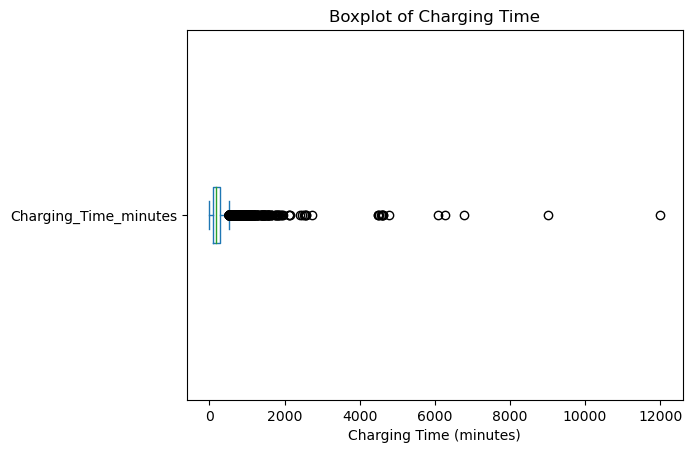

In [43]:
new_df['Charging_Time_minutes'].plot(kind='box', vert=False)
plt.title('Boxplot of Charging Time')
plt.xlabel('Charging Time (minutes)')
plt.show()

In [44]:
Q1 = new_df['Charging_Time_minutes'].quantile(0.25)
Q3 = new_df['Charging_Time_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = new_df[(new_df['Charging_Time_minutes'] < lower_bound)|(new_df['Charging_Time_minutes'] > upper_bound)]
print(outliers)

       Unnamed: 0                        id      connectionTime  \
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
29             29  5e23b149f9af8b5fe4b973ec 2020-01-02 16:28:23   
81             81  5e28f766f9af8b70ebc91c98 2020-01-06 12:32:26   
83             83  5e28f766f9af8b70ebc91c9a 2020-01-06 12:48:56   
89             89  5e28f766f9af8b70ebc91ca0 2020-01-06 13:53:44   
...           ...                       ...                 ...   
66420       10058  5d574ad2f9af8b4c10c03639 2019-07-31 14:04:17   
66421       10059  5d574ad2f9af8b4c10c0363a 2019-07-31 14:05:20   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66442       10080  5d574ad2f9af8b4c10c0364f 2019-07-31 14:48:11   

           disconnectTime    doneChargingTime  kWhDelivered  \
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
29    2020-01-03 03:10:07 2020-01-03 02:46:22        12.082   
81    

In [45]:
print("\nStatisitcal Summary:")
print(outliers.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count   3083.000000                           3083   
mean    4737.656828  2019-06-18 07:44:14.757703424   
min        6.000000            2018-04-26 13:54:17   
25%     1935.000000            2018-11-01 14:18:18   
50%     4067.000000            2019-06-06 13:50:01   
75%     6939.500000            2019-10-30 14:24:57   
max    15289.000000            2021-09-14 05:43:39   
std     3456.282688                            NaN   

                   disconnectTime               doneChargingTime  \
count                        3083                           3083   
mean   2019-06-18 19:44:08.252352  2019-06-18 18:40:50.476808192   
min           2018-04-26 23:08:24            2018-04-26 23:07:12   
25%    2018-11-02 00:02:30.500000            2018-11-01 23:51:16   
50%           2019-06-06 23:30:24            2019-06-06 23:06:09   
75%           2019-10-31 00:17:58     2019-10-31 00:07:59.500000   
max           2

## Finding outliers in the Connection_Time_minutes column

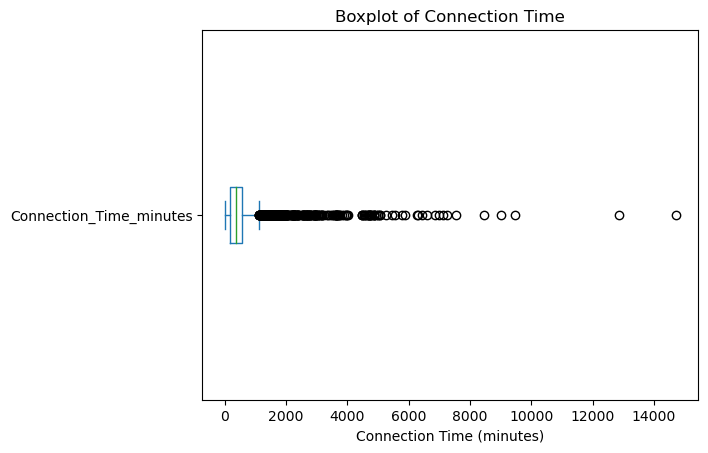

In [46]:
new_df['Connection_Time_minutes'].plot(kind='box', vert=False)
plt.title('Boxplot of Connection Time')
plt.xlabel('Connection Time (minutes)')
plt.show()

In [47]:
Q1_con = new_df['Connection_Time_minutes'].quantile(0.25)
Q3_con = new_df['Connection_Time_minutes'].quantile(0.75)
IQR_con = Q3_con - Q1_con
lower_bound_con = Q1_con - 1.5 * IQR_con
upper_bound_con = Q3_con + 1.5 * IQR_con
outliers_con = new_df[(new_df['Connection_Time_minutes'] < lower_bound_con)|(new_df['Connection_Time_minutes'] > upper_bound_con)]
print(outliers_con)

       Unnamed: 0                        id      connectionTime  \
7246         1673  5d5f33d2f9af8b650c8bfe56 2019-08-07 01:12:26   
7627         2054  5d69bfebf9af8b0682723ef7 2019-08-14 13:00:40   
7911         2338  5d71a8d8f9af8b435820d055 2019-08-20 14:20:30   
8960         3387  5d8d585ff9af8b2ac272ab86 2019-09-11 00:33:34   
11091        5518  5dc4c574f9af8b0159f31844 2019-10-22 23:35:50   
...           ...                       ...                 ...   
61169        4807  5cca3a54f9af8b49aaa4cbee 2019-04-16 00:01:28   
62402        6040  5ce88ce2f9af8b5b259d72f2 2019-05-09 00:09:47   
62651        6289  5cf075ecf9af8b74808d8308 2019-05-14 14:48:06   
63029        6667  5cf85ee3f9af8b11f3749cbe 2019-05-21 00:10:00   
64086        7724  5d16b161f9af8b7bdb8babc7 2019-06-12 13:38:35   

           disconnectTime    doneChargingTime  kWhDelivered  \
7246  2019-08-08 00:03:44 2019-08-07 10:11:52        57.217   
7627  2019-08-16 02:24:39 2019-08-14 14:48:08         4.557   
7911  

In [48]:
print("\nStatisitcal Summary:")
print(outliers_con.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count    467.000000                            467   
mean    5370.653105  2019-04-07 06:32:11.856530944   
min        4.000000            2018-04-25 18:22:03   
25%     2053.000000     2018-08-04 11:16:26.500000   
50%     4370.000000            2018-12-15 21:04:01   
75%     7978.000000     2019-08-08 08:28:25.500000   
max    15289.000000            2021-07-21 16:44:24   
std     3999.135694                            NaN   

                      disconnectTime               doneChargingTime  \
count                            467                            467   
mean   2019-04-08 19:11:27.796573696  2019-04-07 17:50:08.361884160   
min              2018-04-29 00:24:02            2018-04-26 01:41:10   
25%       2018-08-06 09:16:41.500000     2018-08-05 04:43:15.500000   
50%              2018-12-16 20:54:29            2018-12-15 23:13:00   
75%       2019-08-10 00:59:58.500000            2019-08-09 07:53:

## Finding outliers in the kWhDelivered column

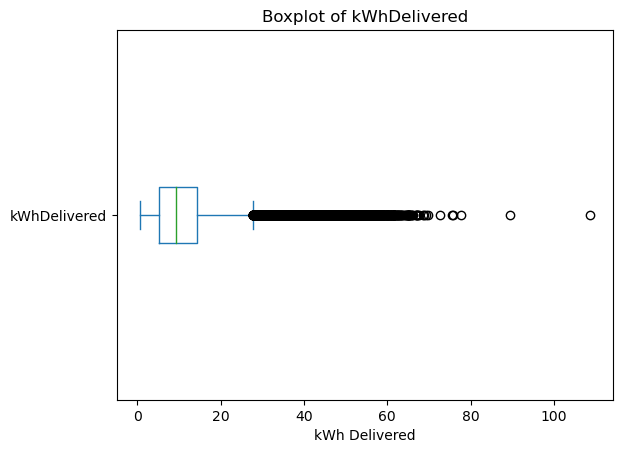

In [49]:
new_df['kWhDelivered'].plot(kind='box', vert=False)
plt.title('Boxplot of kWhDelivered')
plt.xlabel('kWh Delivered')
plt.show()

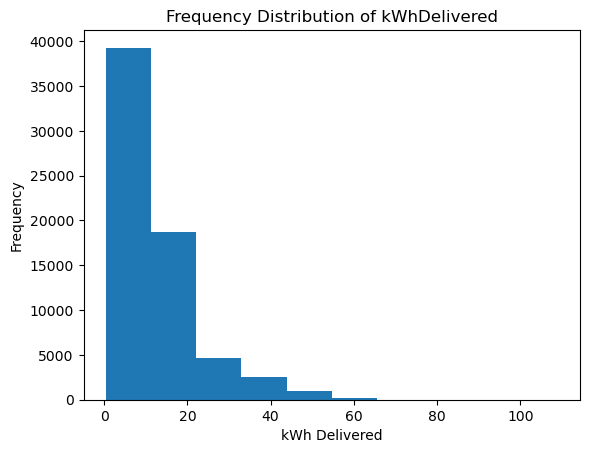

In [50]:
plt.hist(new_df['kWhDelivered'])
plt.title('Frequency Distribution of kWhDelivered')
plt.xlabel('kWh Delivered')
plt.ylabel('Frequency')
plt.show()

In [51]:
Q1_kWh = new_df['kWhDelivered'].quantile(0.25)
Q3_kWh = new_df['kWhDelivered'].quantile(0.75)
IQR_kWh = Q3_kWh - Q1_kWh
lower_bound_kWh = Q1_kWh - 1.5 * IQR_kWh
upper_bound_kWh = Q3_kWh + 1.5 * IQR_kWh
outliers_kWh = new_df[(new_df['kWhDelivered'] < lower_bound_kWh)|(new_df['kWhDelivered'] > upper_bound_kWh)]
print(outliers_kWh)

       Unnamed: 0                        id      connectionTime  \
1               1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
7               7  5e23b149f9af8b5fe4b973d6 2020-01-02 14:17:32   
13             13  5e23b149f9af8b5fe4b973dc 2020-01-02 15:15:27   
21             21  5e23b149f9af8b5fe4b973e4 2020-01-02 15:30:19   
...           ...                       ...                 ...   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66428       10066  5d574ad2f9af8b4c10c03641 2019-07-31 14:30:47   
66433       10071  5d574ad2f9af8b4c10c03646 2019-07-31 14:38:24   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   

           disconnectTime    doneChargingTime  kWhDelivered  \
1     2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
7     

In [52]:
print("\nStatisitcal Summary:")
print(outliers_kWh.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count   5751.000000                           5751   
mean    4156.843679  2019-11-09 08:05:01.848721920   
min        0.000000            2018-04-25 16:25:51   
25%     1653.000000     2019-03-22 13:23:02.500000   
50%     3556.000000            2019-08-29 14:35:02   
75%     5936.000000            2020-02-27 18:54:45   
max    15289.000000            2021-09-14 05:43:39   
std     3145.383383                            NaN   

                      disconnectTime               doneChargingTime  \
count                           5751                           5751   
mean   2019-11-09 16:48:20.922796032  2019-11-09 15:03:19.655190528   
min              2018-04-25 22:30:46            2018-04-25 22:30:41   
25%       2019-03-22 19:58:29.500000     2019-03-22 19:58:20.500000   
50%              2019-08-30 00:23:23            2019-08-29 23:49:56   
75%       2020-02-28 02:55:08.500000            2020-02-28 02:00:

## Merge data using connectionTime as the key

In [53]:
weather_df = pd.read_csv("data/weather_burbank_airport.csv")
print(weather_df.head())

      city            timestamp  temperature  cloud_cover  \
0  Burbank  2018-01-01 08:53:00          9.0         33.0   
1  Burbank  2018-01-01 09:53:00          9.0         33.0   
2  Burbank  2018-01-01 10:53:00          9.0         21.0   
3  Burbank  2018-01-01 11:53:00          9.0         29.0   
4  Burbank  2018-01-01 12:53:00          8.0         33.0   

  cloud_cover_description  pressure  windspeed  precipitation  \
0                    Fair    991.75        9.0            0.0   
1                    Fair    992.08        0.0            0.0   
2                    Haze    992.08        0.0            0.0   
3           Partly Cloudy    992.08        0.0            0.0   
4                    Fair    992.08        0.0            0.0   

   felt_temperature  
0               8.0  
1               9.0  
2               9.0  
3               9.0  
4               8.0  


In [54]:
print(weather_df.describe())

        temperature   cloud_cover      pressure     windspeed  precipitation  \
count  29219.000000  29224.000000  29236.000000  29158.000000   29244.000000   
mean      17.885622     30.107993    986.879400      8.566568       0.059360   
std        6.454604      5.400388      3.607065      6.699889       0.471682   
min        2.000000      4.000000    971.000000      0.000000       0.000000   
25%       13.000000     26.000000    984.500000      6.000000       0.000000   
50%       17.000000     33.000000    986.480000      7.000000       0.000000   
75%       22.000000     34.000000    989.110000     13.000000       0.000000   
max       46.000000     47.000000    999.650000     57.000000      18.540000   

       felt_temperature  
count      29218.000000  
mean          17.731433  
std            6.321100  
min            0.000000  
25%           13.000000  
50%           17.000000  
75%           22.000000  
max           42.000000  


In [55]:
print(weather_df.columns)

Index(['city', 'timestamp', 'temperature', 'cloud_cover',
       'cloud_cover_description', 'pressure', 'windspeed', 'precipitation',
       'felt_temperature'],
      dtype='object')


In [56]:
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
def find_closest_weather(row):
    connection_time = row['connectionTime']
    time_diff = (weather_df['timestamp'] - connection_time).abs()
    closest_index = time_diff.idxmin()
    return weather_df.loc[closest_index]
closest_weather = new_df.apply(find_closest_weather, axis=1)
weather_columns = ['timestamp', 'temperature', 'cloud_cover', 'cloud_cover_description', 'pressure', 'windspeed', 'precipitation', 'felt_temperature']
for col in weather_columns:
    new_df[col] = closest_weather[col].values

In [57]:
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   66423 non-null  float64        
 12  userInputs             

In [58]:
print(new_df.head())

   Unnamed: 0                        id      connectionTime  \
0           0  5e23b149f9af8b5fe4b973cf 2020-01-02 13:08:54   
1           1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
2           2  5e23b149f9af8b5fe4b973d1 2020-01-02 13:56:35   
3           3  5e23b149f9af8b5fe4b973d2 2020-01-02 13:59:58   
4           4  5e23b149f9af8b5fe4b973d3 2020-01-02 14:00:01   

       disconnectTime    doneChargingTime  kWhDelivered  \
0 2020-01-02 19:11:15 2020-01-02 17:31:35        25.016   
1 2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
2 2020-01-03 00:39:22 2020-01-02 16:35:06         6.521   
3 2020-01-02 16:38:39 2020-01-02 15:18:45         2.355   
4 2020-01-02 22:08:40 2020-01-02 18:17:30        13.375   

                                sessionID  siteID  spaceID    stationID  ...  \
0  1_1_179_810_2020-01-02 13:08:53.870034       1  AG-3F30  1-1-179-810  ...   
1  1_1_193_825_2020-01-02 13:36:49.599853       1  AG-1F01  1-1-193-825  ...   
2  1_1_193_829_2020-01-02 

In [59]:
max_value_row = new_df[new_df['connectionTime'] == new_df['connectionTime'].max()]
print(max_value_row)

       Unnamed: 0                        id      connectionTime  \
20178        5875  6155053bf9af8b76960e16d1 2021-09-14 05:43:39   

           disconnectTime    doneChargingTime  kWhDelivered  \
20178 2021-09-14 14:46:28 2021-09-14 14:46:22        53.937   

                                    sessionID  siteID  spaceID    stationID  \
20178  1_1_178_817_2021-09-14 05:43:27.354300       1  AG-1F09  1-1-178-817   

       ... Charging_Time_minutes  Idle_Time_minutes           timestamp  \
20178  ...            542.716667                0.1 2021-01-01 07:53:00   

      temperature cloud_cover cloud_cover_description  pressure  windspeed  \
20178        10.0        33.0                    Fair     987.8        6.0   

       precipitation felt_temperature  
20178            0.0             10.0  

[1 rows x 27 columns]


Since the latest timestamp in the weather file is only up to January 1, 2021, we will also need to fill in the weather information until September 14, 2021.

## Methods for the question: Temporal Patterns and Seasonality: Demonstrate how the number of charging events varies during the day, the week, and between seasons. What patterns can you observe, and how do you explain them? 

def get_active_hours(row):
    start = row['connectionTime']
    end = row['disconnectTime']
    time_range = pd.date_range(start=start, end=end, freq='H')
    return [time.hour for time in time_range]
new_df['active_hours'] = new_df.apply(get_active_hours, axis=1)
all_hours = [hour for hours in new_df['active_hours'] for hour in hours]
hourly_counts = pd.Series(all_hours).value_counts().sort_index()
hourly_counts.plot(kind='bar')
plt.title('Number of Charging Events by Hour (Considering Active Hours)')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Charging Events')
plt.xticks(range(24))
plt.show()

def get_active_weekdays(row):
    start=row['connectionTime'].date()
    end=row['disconnectTime'].date()
    weekday_range=pd.date_range(start=start,end=end,freq='D')
    return [weekday.day_name() for weekday in weekday_range]
new_df['active_weekday'] = new_df.apply(get_active_weekdays,axis=1)
all_weekdays=[weekday for weekdays in new_df['active_weekday'] for weekday in weekdays]
weekly_counts = pd.Series(all_weekdays).value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
weekly_counts.plot(kind='bar')
plt.title('Number of Charging Events by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Charging Events')
plt.show()

def map_season(month):
    if month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Autumn'
    else:
        return 'Winter'
def get_seasons(row):
    date_range=pd.date_range(start=row['connectionTime'],end=row['disconnectTime'])
    seasons=[map_season(date.month)for date in date_range]
    return list(set(seasons))
new_df['seasons']=new_df.apply(get_seasons,axis=1)
all_seasons=[season for seasons in new_df['seasons'] for season in seasons]
seasonal_counts=pd.Series(all_seasons).value_counts().reindex(['Spring', 'Summer', 'Autumn', 'Winter'])
seasonal_counts.plot(kind='bar')
plt.title('Number of Charging Events by Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Charging Events')
plt.show()